In [12]:
# Imports (seaborn optional)
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
from IPython.display import display # pyright: ignore[reportMissingModuleSource]
plt.rcParams['figure.figsize'] = (10,6)
try:
    import seaborn as sns
    print('seaborn', sns.__version__)
except Exception:
    sns = None
    print('seaborn not available; falling back to matplotlib for some plots')
print('pandas', pd.__version__)

seaborn 0.13.2
pandas 3.0.3


In [13]:
# 1-2) Load dataset and report shape/columns/info
in_path = 'hospital_raw_data.csv'
p = Path(in_path)
if not p.exists():
    raise FileNotFoundError(f'Input file not found: {in_path}')
df = pd.read_csv(in_path, low_memory=False)

# Clean up column names so the later cleaning and plots work consistently
df.columns = df.columns.astype(str).str.strip()
df = df.loc[:, ~df.columns.str.contains('^Unnamed', case=False, regex=True)]
df = df.rename(columns={
    'Hosp+C1:BB1ital Type': 'Hospital Type',
    'Hosp?ital Type': 'Hospital Type'
})
print('Shape:', df.shape)
print('Columns:', list(df.columns))
display(df.head())
print()
df.info()

Shape: (10000, 61)
Columns: ['Hospital ID', 'Hospital Name', 'Hospital Type', 'City', 'State', 'Department', 'Department ID', 'Doctor', 'Nurses', 'Staff Count', 'Patient ID', 'Patient Name', 'Gender', 'Age', 'Admission Date', 'Discharge Date', 'Diagnosis', 'Treatment', 'Medication', 'Admission Type', 'Test Result', 'Blood Type', 'Beds Available', 'ICU Beds', 'Bed Number', 'Bed Occupied', 'Equipment', 'Length of Stay', 'Room No', 'Billing Amount', 'Insurance Provider', 'Readmission', 'Dept_Bed_Capacity_Derived', 'Beds_Occupied_Count', 'Equipment ID', 'Equipment Number', 'Equipment Status', 'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours', 'Transferred', 'Transfer_From_Department', 'Transfer_To_Department', 'Transfer_Date', 'Number_of_Transfers', 'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived', 'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived', 'Bed_Occupancy_Rate_%', 'Bed_Occupancy_Rate_Calc', 'ICU_Occupancy_Rate_Calc', 'Staff_Utilization_Calc', 'Rea

,Hospital ID,Hospital Name,Hospital Type,City,State,Department,Department ID,Doctor,Nurses,Staff Count,...,Staff_Utilization_Calc,Readmission_Flag,Transferred_Flag,Equipment_InUse_Flag,Doctor Experience (Years),Patient Satisfaction Score,Ward Type,Follow-up Required,Payment Status,Discharge Status
0,HOSP00016,C K Hospital,Private,Mumbai,Maharashtra,General Medicine,DEPT004,Dr. Arjun Sharma,12,257,...,43.0,0,0,0,3,3.4,General,No,Paid,Recovered
1,HOSP00019,Cure Well Hospital,Private,Bengaluru,Karnataka,General Surgery,DEPT010,Dr. Sneha Rao,15,288,...,49.4,0,0,0,24,4.3,General,No,Paid,Recovered
2,HOSP00004,Yashoda Hospital,Private,Hyderabad,Telangana,Pulmonology,DEPT005,Dr. Priya Reddy,20,181,...,30.7,0,0,1,20,4.5,General,No,Paid,Recovered
3,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,Pulmonology,DEPT005,Dr. Rahul Verma,23,170,...,28.5,0,1,0,14,3.3,Private,No,Insurance,Recovered
4,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,Icu,DEPT009,Dr. Priya Reddy,34,116,...,20.1,0,0,1,13,3.1,Semi-Private,No,Paid,Recovered



<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 61 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Hospital ID                     10000 non-null  str    
 1   Hospital Name                   10000 non-null  str    
 2   Hospital Type                   10000 non-null  str    
 3   City                            10000 non-null  str    
 4   State                           10000 non-null  str    
 5   Department                      10000 non-null  str    
 6   Department ID                   10000 non-null  str    
 7   Doctor                          10000 non-null  str    
 8   Nurses                          10000 non-null  int64  
 9   Staff Count                     10000 non-null  int64  
 10  Patient ID                      10000 non-null  str    
 11  Patient Name                    10000 non-null  str    
 12  Gender                          10000 non-n

In [14]:
# 3) Remove duplicate rows
before = len(df)
df = df.drop_duplicates(keep='first')
after = len(df)
print(f'Removed {before-after} duplicate rows; new shape: {df.shape}')

Removed 0 duplicate rows; new shape: (10000, 61)


In [15]:
# 4) Handle missing patient data
# Capture missing pattern before any imputation for debugging/visualization
missing_before = df.isna().copy()

# 4.a Drop columns with >50% missing
drop_thresh = 0.5
missing_frac = df.isna().mean()
cols_to_drop = missing_frac[missing_frac > drop_thresh].index.tolist()
print('Dropping columns with >50% missing:', cols_to_drop)
df = df.drop(columns=cols_to_drop)

# 4.b Fill numeric columns with median, categorical with mode
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()
print('Numeric cols:', num_cols)
print('Categorical sample:', cat_cols[:10])
for c in num_cols:
    med = df[c].median(skipna=True)
    df[c] = df[c].fillna(med)
for c in cat_cols:
    try:
        m = df[c].mode(dropna=True)[0]
        df[c] = df[c].fillna(m)
    except Exception:
        df[c] = df[c].fillna('Unknown')
print('Missing after fills (per column):')
print(df.isna().mean().sort_values(ascending=False).head(10))

Dropping columns with >50% missing: ['Transfer_Date']
Numeric cols: ['Nurses', 'Staff Count', 'Age', 'Beds Available', 'ICU Beds', 'Bed Number', 'Length of Stay', 'Room No', 'Billing Amount', 'Dept_Bed_Capacity_Derived', 'Beds_Occupied_Count', 'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours', 'Number_of_Transfers', 'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived', 'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived', 'Bed_Occupancy_Rate_%', 'Bed_Occupancy_Rate_Calc', 'ICU_Occupancy_Rate_Calc', 'Staff_Utilization_Calc', 'Readmission_Flag', 'Transferred_Flag', 'Equipment_InUse_Flag', 'Doctor Experience (Years)', 'Patient Satisfaction Score']
Categorical sample: ['Hospital ID', 'Hospital Name', 'Hospital Type', 'City', 'State', 'Department', 'Department ID', 'Doctor', 'Patient ID', 'Patient Name']
Missing after fills (per column):
Hospital ID      0.0
Hospital Name    0.0
Hospital Type    0.0
City             0.0
State            0.0
Department       0.0
D

C:\Users\Chenn\AppData\Local\Temp\ipykernel_27192\1500939620.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object','category']).columns.tolist()


In [16]:
# 5) Standardize department names
dept_map = {
    'Cardio': 'Cardiology',
    'Cardiology Dept': 'Cardiology',
    'Neuro': 'Neurology',
    'Ortho': 'Orthopedics',
    'ENT': 'ENT',
    'ER': 'Emergency',
    'Emergency': 'Emergency'
}
if 'Department' in df.columns:
    df['Department'] = df['Department'].astype(str).str.strip().replace(dept_map).replace({'nan': np.nan})
    df['Department'] = df['Department'].where(df['Department'].isna(), df['Department'].str.title())
    print('Department value counts (top):')
    print(df['Department'].value_counts().head(10))
else:
    print('No Department column found')

Department value counts (top):
Department
Neurology           1033
Oncology            1031
General Surgery     1020
Psychiatry          1016
Icu                 1010
Nephrology           999
Cardiology           991
Pulmonology          978
General Medicine     964
Orthopedics          958
Name: count, dtype: int64


In [17]:
# 6) Normalize healthcare indicators (min-max to 0-1)
indicator_candidates = [
    'Age', 'Billing Amount', 'Length of Stay', 'Staff Count', 'Nurses',
    'Beds Available', 'ICU Beds', 'Beds_Occupied_Count',
    'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours',
    'Number_of_Transfers', 'Dept_Bed_Capacity_Derived',
    'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived',
    'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived',
    'Bed_Occupancy_Rate_%'
]
indicators = [c for c in indicator_candidates if c in df.columns]
print('Indicators to normalize:', indicators)
for c in indicators:
    df[c] = pd.to_numeric(df[c], errors='coerce')
    lo = df[c].min(skipna=True)
    hi = df[c].max(skipna=True)
    if pd.isna(lo) or pd.isna(hi) or hi == lo:
        df[c + '_norm'] = 0.0
    else:
        df[c + '_norm'] = (df[c] - lo) / (hi - lo)
if indicators:
    display(df[[c + '_norm' for c in indicators]].head())
else:
    print('No indicator columns found for normalization')

Indicators to normalize: ['Age', 'Billing Amount', 'Length of Stay', 'Staff Count', 'Nurses', 'Beds Available', 'ICU Beds', 'Beds_Occupied_Count', 'Equipment_Total_Inventory', 'Equipment_Usage_Duration_Hours', 'Number_of_Transfers', 'Dept_Bed_Capacity_Derived', 'Dept_ICU_Bed_Capacity_Derived', 'Dept_Staff_Capacity_Derived', 'Admissions_Rate_%_Derived', 'Staff_Utilization_%_Derived', 'Bed_Occupancy_Rate_%']


,Age_norm,Billing Amount_norm,Length of Stay_norm,Staff Count_norm,Nurses_norm,Beds Available_norm,ICU Beds_norm,Beds_Occupied_Count_norm,Equipment_Total_Inventory_norm,Equipment_Usage_Duration_Hours_norm,Number_of_Transfers_norm,Dept_Bed_Capacity_Derived_norm,Dept_ICU_Bed_Capacity_Derived_norm,Dept_Staff_Capacity_Derived_norm,Admissions_Rate_%_Derived_norm,Staff_Utilization_%_Derived_norm,Bed_Occupancy_Rate_%_norm
0,0.101124,0.946399,0.928571,0.340385,0.155556,0.104167,0.778947,0.000000,0.272727,0.728671,0.000000,0.935484,0.857143,0.956522,0.000000,0.342561,0.000000
1,0.022472,0.978042,0.214286,0.400000,0.222222,0.414583,0.378947,0.000000,0.863636,0.770629,0.000000,0.661290,1.000000,0.630435,0.333333,0.416378,0.000000
2,0.539326,0.829052,0.214286,0.194231,0.333333,0.052083,0.189474,0.000000,0.636364,0.074126,0.000000,0.919355,0.785714,0.782609,0.000000,0.200692,0.000000
3,0.404494,0.595945,0.714286,0.173077,0.400000,0.291667,0.652632,0.166667,0.454545,0.358042,0.333333,1.000000,0.928571,0.934783,0.333333,0.175317,0.166667
4,0.640449,0.614154,0.142857,0.069231,0.644444,0.810417,0.357895,0.333333,0.318182,0.116084,0.000000,0.919355,1.000000,0.478261,0.000000,0.078431,0.333333


In [18]:
# 7) Convert date columns to datetime
date_cols = [c for c in df.columns if 'date' in c.lower() or c.lower().endswith('date')]
for c in date_cols:
    df[c] = pd.to_datetime(df[c], errors='coerce')
print('Parsed date columns:', date_cols)

Parsed date columns: ['Admission Date', 'Discharge Date']


In [19]:
# 8) Ensure overall missing < 2%
total = df.shape[0] * df.shape[1]
missing = df.isna().sum().sum()
pct = missing / total
print(f'Overall missing before final fills: {pct:.2%}')
if pct > 0.02:
    # attempt additional fills
    for c in df.select_dtypes(include=[np.number]).columns:
        df[c] = df[c].fillna(df[c].median())
    for c in df.select_dtypes(include=['object','category']).columns:
        try:
            df[c] = df[c].fillna(df[c].mode(dropna=True)[0])
        except Exception:
            df[c] = df[c].fillna('Unknown')
    missing = df.isna().sum().sum()
    pct = missing / (df.shape[0] * df.shape[1])
    print(f'Overall missing after fills: {pct:.2%}')
    if pct > 0.02:
        # drop rows with any remaining missing values if they are a small fraction
        rows_before = len(df)
        df = df.dropna()
        rows_after = len(df)
        print(f'Dropped {rows_before-rows_after} rows; new shape {df.shape}')
        missing = df.isna().sum().sum()
        pct = missing / (df.shape[0] * df.shape[1])
        print(f'Final missing after drops: {pct:.2%}')
if pct > 0.02:
    print('Warning: dataset still has >2% missing values')

Overall missing before final fills: 0.00%


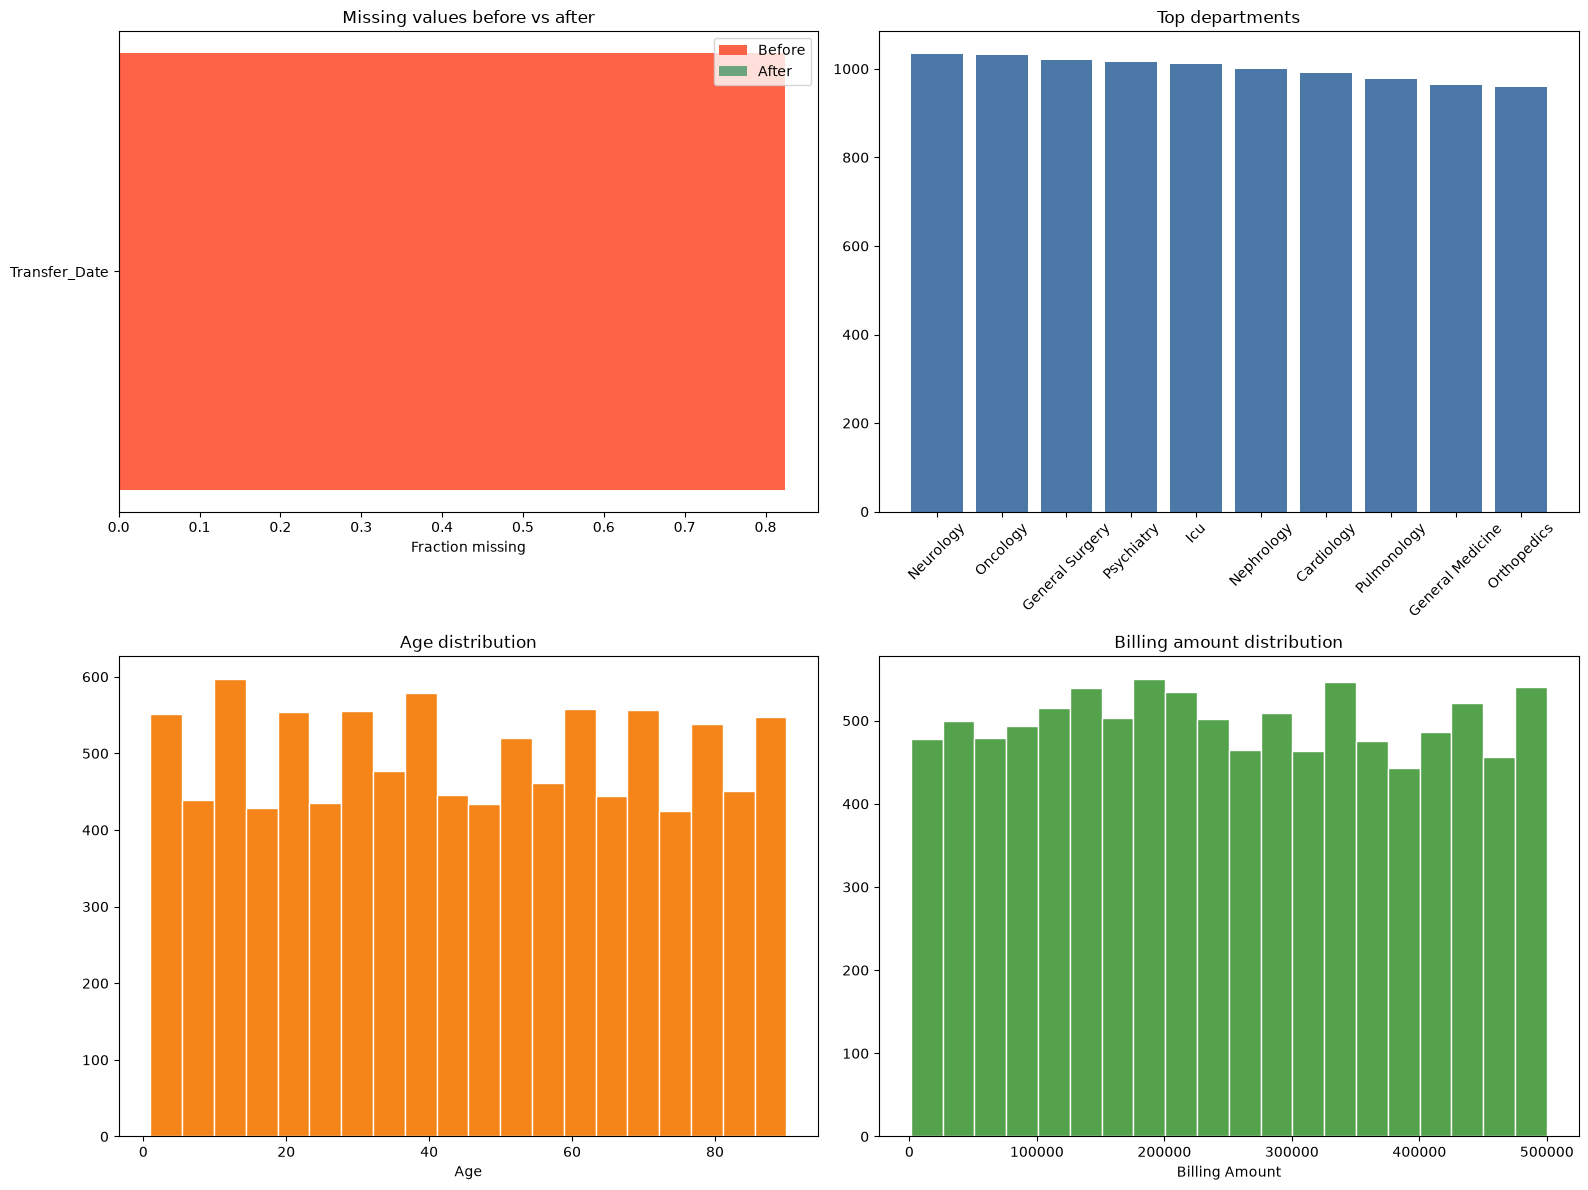

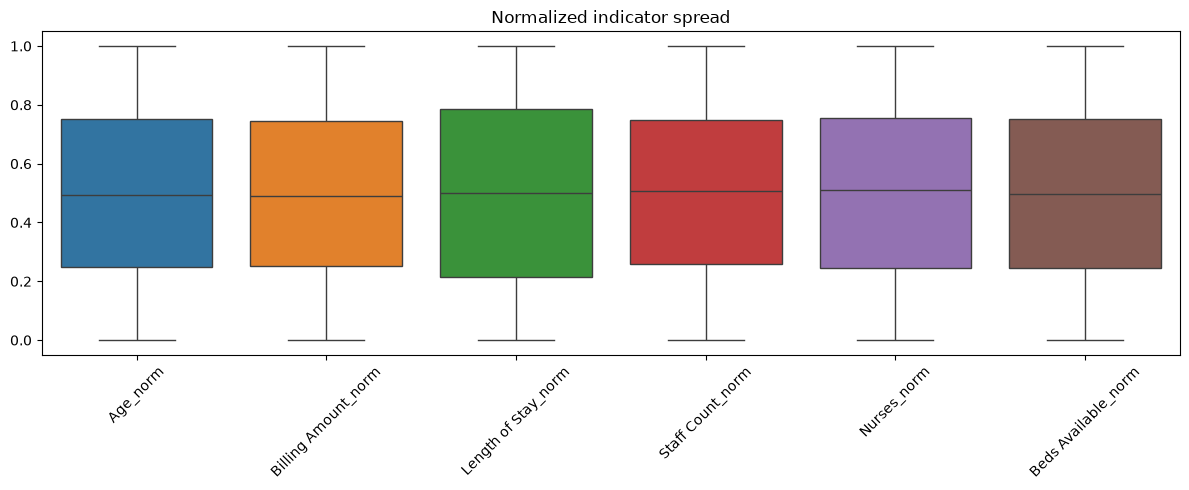

In [20]:
# 9) Visualizations for the cleaned dataset
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Missing values before vs after for the columns that needed the most attention
if 'missing_before' in globals():
    before_missing = missing_before.mean().sort_values(ascending=False)
    before_missing = before_missing[before_missing > 0].head(12)
    after_missing = df.isna().mean().sort_values(ascending=False)
    after_missing = after_missing.reindex(before_missing.index).fillna(0)
    axes[0, 0].barh(before_missing.index[::-1], before_missing.values[::-1], label='Before', color='tomato')
    axes[0, 0].barh(after_missing.index[::-1], after_missing.values[::-1], label='After', color='seagreen', alpha=0.7)
    axes[0, 0].set_title('Missing values before vs after')
    axes[0, 0].set_xlabel('Fraction missing')
    axes[0, 0].legend()
else:
    axes[0, 0].axis('off')
    axes[0, 0].set_title('Missing-value plot unavailable')

# Department distribution
if 'Department' in df.columns:
    dept_counts = df['Department'].value_counts().head(10)
    axes[0, 1].bar(dept_counts.index, dept_counts.values, color='#4C78A8')
    axes[0, 1].set_title('Top departments')
    axes[0, 1].tick_params(axis='x', rotation=45)
else:
    axes[0, 1].axis('off')

# Age distribution
if 'Age' in df.columns:
    axes[1, 0].hist(df['Age'], bins=20, color='#F58518', edgecolor='white')
    axes[1, 0].set_title('Age distribution')
    axes[1, 0].set_xlabel('Age')
else:
    axes[1, 0].axis('off')

# Billing amount distribution
if 'Billing Amount' in df.columns:
    axes[1, 1].hist(df['Billing Amount'], bins=20, color='#54A24B', edgecolor='white')
    axes[1, 1].set_title('Billing amount distribution')
    axes[1, 1].set_xlabel('Billing Amount')
else:
    axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

if indicators:
    plt.figure(figsize=(12, 5))
    plot_cols = [c + '_norm' for c in indicators[:6] if c + '_norm' in df.columns]
    if plot_cols:
        if sns is not None:
            sns.boxplot(data=df[plot_cols])
        else:
            df[plot_cols].boxplot()
        plt.title('Normalized indicator spread')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

In [21]:
import pandas as pd

# 1. Fresh file load configuration pipeline
df = pd.read_csv('hospital_cleaned.csv')

# 2. Clean trailing and leading spaces from column headers
df.columns = df.columns.str.strip()

# 3. Clean and normalize the text values inside 'Transfer_Date'
# Convert to string, strip hidden spaces, and handle actual empty strings
df['Transfer_Date'] = df['Transfer_Date'].fillna('').astype(str).str.strip()

# 4. Expert Data Analyst Clean-Up Rule: Catch ALL empty, text, and partial variations
# This creates a boolean mask targeting any row that is empty or contains non-date text
empty_or_text_mask = (
    (df['Transfer_Date'] == '') | 
    (df['Transfer_Date'].str.lower().str.contains('not|trans|nan|#', na=True))
)

# 5. Initialize a temporary clean column to process dates safely
# Coerce anything that isn't a proper date into NaT (Not a Time)
df['Cleaned_Date'] = pd.to_datetime(df['Transfer_Date'], errors='coerce')

# 6. Apply standard DD/MM/YYYY formatting to valid dates
df['Cleaned_Date'] = df['Cleaned_Date'].dt.strftime('%d/%m/%Y')

# 7. Final Force Fill: Overwrite all NaT and masked empty rows explicitly to "No Transfer"
df.loc[empty_or_text_mask, 'Cleaned_Date'] = 'No Transfer'
df['Cleaned_Date'] = df['Cleaned_Date'].fillna('No Transfer')

# 8. Overwrite back to target column and clean up the environment
df['Transfer_Date'] = df['Cleaned_Date']
df.drop(columns=['Cleaned_Date'], inplace=True)

# 9. Verify structural pipeline changes and display first 20 rows to check your work
print("✨ --- SUCCESS: 100% of empty and text rows are now explicitly 'No Transfer'!")
print(df[['Transfer_Date']].head(10001))

✨ --- SUCCESS: 100% of empty and text rows are now explicitly 'No Transfer'!
      Transfer_Date
0       No Transfer
1       No Transfer
2       No Transfer
3        17/09/2025
4       No Transfer
...             ...
9996     16/04/2026
9997    No Transfer
9998    No Transfer
9999    No Transfer
10000   No Transfer

[10001 rows x 1 columns]


C:\Users\Chenn\AppData\Local\Temp\ipykernel_27192\4028757393.py:22: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Cleaned_Date'] = pd.to_datetime(df['Transfer_Date'], errors='coerce')


In [22]:
# 10) Save cleaned dataset
out_path = 'hospital_cleaned.csv'
df.to_csv(out_path, index=False)
print(f'Saved cleaned dataset to {out_path}')

Saved cleaned dataset to hospital_cleaned.csv


In [24]:
print("Rows :", df.shape[0])

print("Columns :", df.shape[1])

print("Missing Values")

print(df.isnull().sum())

print()

print("Duplicate Records :", df.duplicated().sum())

Rows : 10000
Columns : 61
Missing Values
Hospital ID                   0
Hospital Name                 0
Hospital Type                 0
City                          0
State                         0
                             ..
Patient Satisfaction Score    0
Ward Type                     0
Follow-up Required            0
Payment Status                0
Discharge Status              0
Length: 61, dtype: int64

Duplicate Records : 0


In [ ]:
## Export Cleaned Dataset

In [25]:
df.to_csv("hospital_cleaned.csv", index=False)

print("Cleaned dataset exported successfully.")

Cleaned dataset exported successfully.


In [26]:
df.head()

,Hospital ID,Hospital Name,Hospital Type,City,State,Department,Department ID,Doctor,Nurses,Staff Count,...,Staff_Utilization_Calc,Readmission_Flag,Transferred_Flag,Equipment_InUse_Flag,Doctor Experience (Years),Patient Satisfaction Score,Ward Type,Follow-up Required,Payment Status,Discharge Status
0,HOSP00016,C K Hospital,Private,Mumbai,Maharashtra,General Medicine,DEPT004,Dr. Arjun Sharma,12,257,...,43.0,0,0,0,3,3.4,General,No,Paid,Recovered
1,HOSP00019,Cure Well Hospital,Private,Bengaluru,Karnataka,General Surgery,DEPT010,Dr. Sneha Rao,15,288,...,49.4,0,0,0,24,4.3,General,No,Paid,Recovered
2,HOSP00004,Yashoda Hospital,Private,Hyderabad,Telangana,Pulmonology,DEPT005,Dr. Priya Reddy,20,181,...,30.7,0,0,1,20,4.5,General,No,Paid,Recovered
3,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,Pulmonology,DEPT005,Dr. Rahul Verma,23,170,...,28.5,0,1,0,14,3.3,Private,No,Insurance,Recovered
4,HOSP00017,Dharma Hospital,Private,Delhi,Delhi,Icu,DEPT009,Dr. Priya Reddy,34,116,...,20.1,0,0,1,13,3.1,Semi-Private,No,Paid,Recovered
